# RETFound Fine-Tuning

**Model:** RETFound (Retinal Foundation Model) — Vision Transformer pretrained with Masked Autoencoder (MAE)  
**Task:** Binary glaucoma classification (Non-Glaucoma vs Glaucoma)  
**Dataset:** Color fundus photographs (CFP)  
**Fine-Tuning Strategies Compared:**
- **Section 1 — Partial Fine-Tuning:** Unfreeze only the last transformer block and classification head

---

## Table of Contents
- [Partial Fine-Tuning (Last Block + Head)](#section-1)
   - 1.1 Environment Setup & Model Loading
   - 1.2 Dataset Preparation
   - 1.3 Baseline Evaluation (Before Fine-Tuning)
   - 1.4 Fine-Tuning Configuration
   - 1.5 Training Loop
   - 1.6 Bootstrap Evaluation
   - 1.7 Attention Rollout Visualization

---

<a id='section-1'></a>
# Partial Fine-Tuning (Last Block + Head)

> **Strategy:** Freeze the entire backbone. Unfreeze only the last transformer block and the classification head.  
> This is the most lightweight fine-tuning approach — it adapts just the final decision layers while keeping all pretrained representations intact.

---

## 1.1 Environment Setup & Model Loading

We start by verifying the working directory, seeding all random sources for reproducibility, and loading the pretrained RETFound weights from Hugging Face.

In [1]:
# Print the current working directory to confirm the starting path.
import os
print(os.getcwd())

C:\Users\Rama Alotaibi


In [2]:
# Navigate into the RETFound directory where models_vit.py lives.
import os
os.chdir("RETFound") 

In [3]:
# List directory contents to confirm all required files are present.
!dir

 Volume in drive C is Windows
 Volume Serial Number is 7266-FD74

 Directory of C:\Users\Rama Alotaibi\RETFound

02/24/2026  11:41 AM    <DIR>          .
05/17/2026  10:32 AM    <DIR>          ..
01/25/2026  09:16 AM             1,981 .gitignore
02/03/2026  01:35 PM     1,213,332,618 1.5_retfound_glaucoma.pth
02/03/2026  01:55 PM     1,213,332,618 932_retfound_glaucoma.pth
01/25/2026  09:16 AM             4,239 BENCHMARK.md
02/01/2026  01:56 PM     1,213,329,318 best_model.pth
02/03/2026  01:01 PM     1,213,332,982 best_retfound_glaucoma.pth
02/17/2026  01:24 PM     1,213,330,282 cv_fold1_best.pth
02/17/2026  01:32 PM     1,213,330,282 cv_fold2_best.pth
02/17/2026  01:42 PM     1,213,330,282 cv_fold3_best.pth
02/17/2026  01:50 PM     1,213,330,282 cv_fold4_best.pth
02/17/2026  01:59 PM     1,213,330,282 cv_fold5_best.pth
02/17/2026  03:07 PM     1,218,194,104 cv_lora_fold1_best.pth
02/17/2026  03:20 PM     1,218,194,104 cv_lora_fold2_best.pth
02/17/2026  03:36 PM     1,218,194,104 cv_l

In [4]:
# Fix all random seeds so results are reproducible across runs.
# # - Covers Python, NumPy, PyTorch, and CUDA.
# # - seed_worker ensures DataLoader workers are also seeded.

import random
import numpy as np
import torch


def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

set_seed(42)

In [5]:
# Download the pretrained RETFound weights from Hugging Face.
# # - Uses the color fundus photo (CFP) variant trained with masked autoencoder (MAE).

from huggingface_hub import hf_hub_download

weights_path = hf_hub_download(
    repo_id="YukunZhou/RETFound_mae_natureCFP",
    filename="RETFound_mae_natureCFP.pth"
)

print(weights_path)

C:\Users\Rama Alotaibi\.cache\huggingface\hub\models--YukunZhou--RETFound_mae_natureCFP\snapshots\556830f78214f0e8da35af965292ac5a3180ac47\RETFound_mae_natureCFP.pth


In [6]:
# Import the RETFound Vision Transformer architecture.
import torch
from models_vit import RETFound_mae

In [7]:
# Build the RETFound model with 2 output classes (glaucoma / non-glaucoma).
model = RETFound_mae(
    num_classes=2
)

In [8]:
# Load pretrained weights with strict=False to allow partial loading (head is new).
checkpoint = torch.load(weights_path, map_location="cpu")

model.load_state_dict(
    checkpoint["model"],
    strict=False
)

C:\Users\Rama Alotaibi\AppData\Local\Temp\ipykernel_24132\1674944397.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weights_path, map_location="

_IncompatibleKeys(missing_keys=['head.weight', 'head.bias'], unexpected_keys=['mask_token', 'decoder_pos_embed', 'decoder_embed.weight', 'decoder_embed.bias', 'decoder_blocks.0.norm1.weight', 'decoder_blocks.0.norm1.bias', 'decoder_blocks.0.attn.qkv.weight', 'decoder_blocks.0.attn.qkv.bias', 'decoder_blocks.0.attn.proj.weight', 'decoder_blocks.0.attn.proj.bias', 'decoder_blocks.0.norm2.weight', 'decoder_blocks.0.norm2.bias', 'decoder_blocks.0.mlp.fc1.weight', 'decoder_blocks.0.mlp.fc1.bias', 'decoder_blocks.0.mlp.fc2.weight', 'decoder_blocks.0.mlp.fc2.bias', 'decoder_blocks.1.norm1.weight', 'decoder_blocks.1.norm1.bias', 'decoder_blocks.1.attn.qkv.weight', 'decoder_blocks.1.attn.qkv.bias', 'decoder_blocks.1.attn.proj.weight', 'decoder_blocks.1.attn.proj.bias', 'decoder_blocks.1.norm2.weight', 'decoder_blocks.1.norm2.bias', 'decoder_blocks.1.mlp.fc1.weight', 'decoder_blocks.1.mlp.fc1.bias', 'decoder_blocks.1.mlp.fc2.weight', 'decoder_blocks.1.mlp.fc2.bias', 'decoder_blocks.2.norm1.weigh

In [9]:
# Inspect available attributes in models_vit to confirm the module loaded correctly.
import models_vit
dir(models_vit)

['Dinov2',
 'Dinov3',
 'F',
 'RETFound_dinov2',
 'RETFound_mae',
 'Tensor',
 'VisionTransformer',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'nn',
 'partial',
 'timm',
 'torch',
 'trunc_normal_']

In [10]:
# Set model to eval mode to confirm it runs before any training.
model.eval()
print("RETFound_mae_natureCFP is fully loaded and ready")


RETFound_mae_natureCFP is fully loaded and ready


In [11]:
print(model)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=1024, out_features=3072, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Id

## 1.2 Dataset Preparation

The dataset follows a standard `ImageFolder` structure with three splits: `training`, `val`, and `test`,
using a **60/20/20 split ratio** (60% training, 20% validation, 20% test).
Each split contains two class folders: `A_non_glaucoma` and `B_glaucoma`.

**Training augmentations** introduce controlled variation to reduce overfitting:
flips, rotation, crop, color jitter, Gaussian blur, and random erasing.
**Validation / test transforms** apply only resize and normalization for consistent, unbiased evaluation.

### Combined ROI Dataset

This is the primary dataset used for training the partial fine-tuning model. Image counts per class and split are printed below to confirm the class balance.

In [12]:
# Import image loading and transformation utilities.
import torch
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [13]:
# Check image counts for the Combined ROI dataset — this is the main dataset used for training.
import os

base_dir = r"D:\Rama\Glaucoma test\RETFound\RetFoundDatasets_60_20_20"

for split in ["training", "val", "test"]:
    print(f"\n{split.upper()}")
    for cls in ["A_non_glaucoma" , "B_glaucoma"]:
        path = os.path.join(base_dir, split, cls)
        print(cls, len(os.listdir(path)))


TRAINING
A_non_glaucoma 828
B_glaucoma 731

VAL
A_non_glaucoma 276
B_glaucoma 243

TEST
A_non_glaucoma 277
B_glaucoma 245


In [14]:
# Define augmentations for training images.
# # - Flips, rotation, crop, color jitter, blur, and random erasing all increase variety.
# # - Normalize with ImageNet stats, which RETFound expects.

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.05),
    transforms.RandomRotation(degrees=15),
    transforms.RandomResizedCrop(
        size=224,
        scale=(0.85, 1.0),
        ratio=(0.9, 1.1)
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.1,
        hue=0.03
    ),

   transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))
    ], p=0.3),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),

   transforms.RandomErasing(
        p=0.05,
        scale=(0.02, 0.1),
        ratio=(0.3, 3.3)
    )
])

In [15]:
# Define transforms for val/test images.
# # - No augmentation — only resize and normalize for consistent evaluation.

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

In [16]:
# Load images from folder structure using ImageFolder.
# # - Folder names become class labels automatically.

data_dir = base_dir

train_dataset = datasets.ImageFolder(
    root=f"{data_dir}/training",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=f"{data_dir}/val",
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    root=f"{data_dir}/test",
    transform=eval_transform
)

In [17]:
# Print the class-to-index mapping to confirm label assignment.
print("Class to index mapping:", train_dataset.class_to_idx)

Class to index mapping: {'A_non_glaucoma': 0, 'B_glaucoma': 1}


In [18]:
# Create DataLoaders to feed batches of 8 images to the model.
# # - Shuffle only the training set; keep val/test in fixed order.

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    generator=g
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

In [19]:
# Move the model to GPU if available, otherwise CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Model running on: {device}")

Model running on: cuda


## 1.3 Baseline Evaluation (Before Fine-Tuning)

We run the pretrained RETFound model on the test set **without any fine-tuning** to establish a zero-shot baseline.  
This tells us exactly how much improvement the fine-tuning step contributes.

We also run a pipeline sanity check: one forward pass, NaN/Inf inspection, softmax probabilities, and a determinism test.

In [20]:
# Grab one batch from the training loader to test the pipeline.
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

In [21]:
# Run one forward pass and check the output.
# # - NaN/Inf checks catch any weight or input issues early.

model.eval()
with torch.no_grad():
    outputs = model(images)

print("Output shape:", outputs.shape)
print("NaN check:", torch.isnan(outputs).any().item())
print("Inf check:", torch.isinf(outputs).any().item())

Output shape: torch.Size([8, 2])
NaN check: False
Inf check: False


In [22]:
# Convert raw model outputs to probabilities using softmax.
# # - Shows predicted confidence per class for the first 3 samples.

probs = F.softmax(outputs, dim=1)

print("\nSample probabilities:")
for i in range(min(3, len(probs))):
    print(
        f"Sample {i}: A_non_glaucoma={probs[i][0]:.4f}, "
        f"B_glaucoma={probs[i][1]:.4f}"
    )


Sample probabilities:
Sample 0: A_non_glaucoma=0.2315, B_glaucoma=0.7685
Sample 1: A_non_glaucoma=0.2415, B_glaucoma=0.7585
Sample 2: A_non_glaucoma=0.1814, B_glaucoma=0.8186


In [23]:
# Compare the model predictions against the true labels for each image in the batch.
preds = torch.argmax(outputs, dim=1)
print("\nPredictions vs labels:")
for i in range(len(preds)):
    print(
        f"Image {i}: Pred={[preds[i].item()]} | "
        f"True={[labels[i].item()]} | "
        f"{'True' if preds[i]==labels[i] else 'False'}"
    )


Predictions vs labels:
Image 0: Pred=[1] | True=[1] | True
Image 1: Pred=[1] | True=[0] | False
Image 2: Pred=[1] | True=[0] | False
Image 3: Pred=[1] | True=[0] | False
Image 4: Pred=[0] | True=[1] | False
Image 5: Pred=[1] | True=[1] | True
Image 6: Pred=[0] | True=[0] | True
Image 7: Pred=[1] | True=[1] | True


In [24]:
# Run the same batch twice and check if outputs are identical.
# # - Confirms deterministic behavior (important for reproducibility).

with torch.no_grad():
    out1 = model(images)
    out2 = model(images)

print("Model deterministic:", torch.allclose(out1, out2))

Model deterministic: True


In [25]:
# Define a reusable function to compute accuracy over any dataloader.
# # - Loops through all batches without computing gradients (faster, no memory waste).

def evaluate_model(model, loader, device):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [26]:
# Run the evaluate function on the test set before any fine-tuning.
# # - This is the baseline we compare against after training.

test_accuracy = evaluate_model(model, test_loader, device)
print(f"Test Accuracy (before fine-tuning): {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Test Accuracy (before fine-tuning): 0.4923 (49.23%)


## 1.4 Fine-Tuning Configuration

**Parameter freezing strategy:**
- All backbone layers are frozen first.
- Only the **last transformer block** (`model.blocks[-1]`) and the **classification head** are unfrozen.

**Loss function — Weighted Focal Loss:**
- Class weights are computed from training set counts to address class imbalance.
- The focal factor (`γ=2`) reduces the contribution of easy, correctly-classified examples, directing training effort toward hard cases.

**Optimizer:** AdamW (`lr=1e-4`, `weight_decay=0.01`) — standard for fine-tuning transformers.  
**Scheduler:** Cosine Annealing with Warm Restarts — periodically resets the learning rate to escape local minima.  
**Regularization:** Dropout(0.3) inserted before the classification head.

In [27]:
# Import required modules for the model, loss, and scheduler.
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn as nn

In [28]:
# Freeze all model parameters as the starting point.
for param in model.parameters():
    param.requires_grad = False

In [29]:
# Unfreeze only the last transformer block and the classification head.
# # - These are the only layers that will be updated during training.

for param in model.blocks[-1].parameters():
   param.requires_grad = True

for param in model.head.parameters():
    param.requires_grad = True


In [30]:
# Add Dropout(0.3) before the classification head.
# # - Reduces overfitting by randomly deactivating neurons during training.

original_head = model.head
model.head = nn.Sequential(
    nn.Dropout(p=0.3),
    original_head
)
model = model.to(device)

In [31]:
# Define Weighted Focal Loss to handle class imbalance.
# # - Class weights are computed from training set counts, giving more weight to the minority class (glaucoma).
# # - Focal factor down-weights easy examples so the model focuses on hard ones.

import os
import torch
import torch.nn as nn
import torch.nn.functional as F


class WeightedFocalLoss(nn.Module):
    def __init__(self, class_weights=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.class_weights = class_weights
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits,
            targets,
            weight=self.class_weights,
            reduction="none"
        )

        pt = torch.exp(-ce_loss)
        loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss

num_non_glaucoma = len(os.listdir(os.path.join(base_dir, "training", "A_non_glaucoma")))
num_glaucoma = len(os.listdir(os.path.join(base_dir, "training", "B_glaucoma")))

class_counts = torch.tensor(
    [num_non_glaucoma, num_glaucoma],
    dtype=torch.float,
    device=device
)

class_weights = class_counts.sum() / class_counts
class_weights = class_weights / class_weights.sum()

print(
    f"Class weights: "
    f"Non-glaucoma={class_weights[0]:.3f}, "
    f"Glaucoma={class_weights[1]:.3f}"
)

criterion = WeightedFocalLoss(
    class_weights=class_weights,
    gamma=2.0
)

Class weights: Non-glaucoma=0.469, Glaucoma=0.531


In [32]:
# Import the optimizer module.
import torch.optim as optim

In [33]:
# Set up AdamW optimizer on trainable parameters only.
# # - lr=1e-4 and weight_decay=0.01 are standard choices for fine-tuning transformers.

trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=1e-4, weight_decay=0.01)

In [34]:
# Import the learning rate scheduler.
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

In [35]:
# Use cosine annealing with warm restarts to adjust the learning rate.
# # - Periodically resets the LR so the model can escape local minima.

scheduler = CosineAnnealingWarmRestarts(
    optimizer,
    T_0=5,
    T_mult=2
)

In [36]:
# Get the integer index of the glaucoma class.
# # - Needed to extract the correct probability column for AUC computation.

pos_idx = val_dataset.class_to_idx["B_glaucoma"]

## 1.5 Training Loop

The model trains for up to **50 epochs** with the following protocol:
- Validation AUC is computed at the end of every epoch.
- The best checkpoint is saved automatically when AUC improves.
- **Early stopping** triggers if AUC does not improve for 5 consecutive epochs (`patience=5`).
- Normalization layers (BatchNorm, LayerNorm) are kept in eval mode throughout training to maintain stable statistics.

Two checkpoint formats are saved: a lightweight state dict and a full fusion-ready checkpoint (includes optimizer, scheduler, normalization info).

In [37]:
# Main training loop.
# # - Trains the model each epoch, then evaluates on the validation set.
# # - Saves the model when validation AUC improves (two formats: state dict and full checkpoint).
# # - Stops early if AUC does not improve for 5 consecutive epochs (patience=5).
# # - Norm layers kept in eval mode to avoid unstable batch statistics.

from sklearn.metrics import roc_auc_score

num_epochs = 50
best_val_auc = -1
patience = 5
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    model.train()
    for m in model.modules():
        if isinstance(m, (torch.nn.BatchNorm2d, torch.nn.LayerNorm)):
            m.eval()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    avg_train_loss = train_loss / len(train_loader)
    train_acc = train_correct / train_total
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0

    y_val_true = []
    y_val_prob = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            probs = torch.softmax(outputs, dim=1)[:, pos_idx]
            y_val_true.extend(labels.detach().cpu().numpy())
            y_val_prob.extend(probs.detach().cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    y_val_true = np.array(y_val_true)
    y_val_prob = np.array(y_val_prob)

    if len(np.unique(y_val_true)) < 2:
        val_auc = float("nan")
    else:
        val_auc = roc_auc_score(y_val_true, y_val_prob)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {avg_val_loss:.4f} | Val   AUC: {val_auc:.4f}")

    scheduler.step(epoch + 1)

    if (not np.isnan(val_auc)) and (val_auc > best_val_auc):
        best_val_auc = val_auc
        patience_counter = 0
        torch.save(model.state_dict(), r"D:\Rama\RetFound.pth")
        print("✓ Model saved (best Val AUC)")

        torch.save({
         "model_state_dict": model.state_dict(),
         "optimizer_state_dict": optimizer.state_dict(),
         "scheduler_state_dict": scheduler.state_dict(),
         "epoch": epoch,
         "best_val_auc": best_val_auc,
         "class_to_idx": train_dataset.class_to_idx,
         "normalization": {
             "mean": [0.485, 0.456, 0.406],
             "std":  [0.229, 0.224, 0.225]
         },
         "input_size": 224,
        }, r"D:\Rama\RetFound_FULL.pth")
        print("✓ Full fusion-ready checkpoint saved")


    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered")
        break

print("Best Val AUC:", best_val_auc)


C:\Users\Rama Alotaibi\anaconda3\envs\retfound\lib\site-packages\torch\autograd\graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
C:\Users\Rama Alotaibi\anaconda3\envs\retfound\lib\site-packages\torch\autograd\graph.py:825: UserWarning: Memory Efficient attention defaults to 

Epoch 1/50
Train Loss: 0.0355 | Train Acc: 0.5491
Val   Loss: 0.0255 | Val   AUC: 0.7354
✓ Model saved (best Val AUC)
✓ Full fusion-ready checkpoint saved


C:\Users\Rama Alotaibi\anaconda3\envs\retfound\lib\site-packages\torch\autograd\graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 2/50
Train Loss: 0.0280 | Train Acc: 0.6402
Val   Loss: 0.0252 | Val   AUC: 0.8242
✓ Model saved (best Val AUC)
✓ Full fusion-ready checkpoint saved


C:\Users\Rama Alotaibi\anaconda3\envs\retfound\lib\site-packages\torch\autograd\graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


...

Epoch 24/50
Train Loss: 0.0162 | Train Acc: 0.8024
Val   Loss: 0.0171 | Val   AUC: 0.9000


C:\Users\Rama Alotaibi\anaconda3\envs\retfound\lib\site-packages\torch\autograd\graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 25/50
Train Loss: 0.0155 | Train Acc: 0.8146
Val   Loss: 0.0166 | Val   AUC: 0.9035


C:\Users\Rama Alotaibi\anaconda3\envs\retfound\lib\site-packages\torch\autograd\graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 26/50
Train Loss: 0.0154 | Train Acc: 0.8217
Val   Loss: 0.0165 | Val   AUC: 0.9065
Early stopping triggered
Best Val AUC: 0.9073030357249359


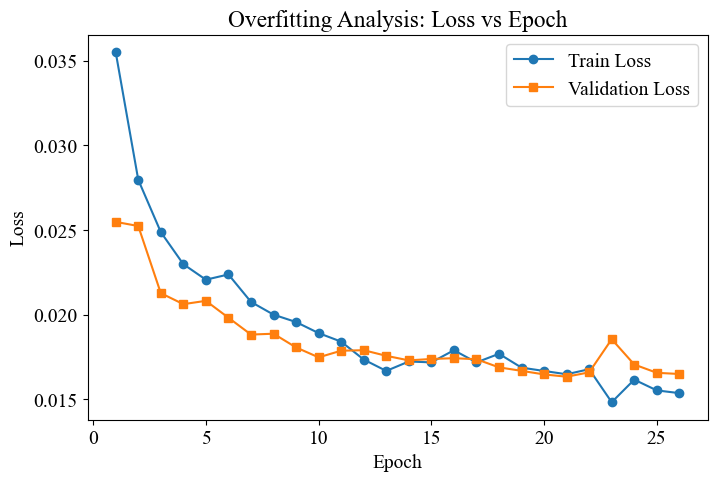

In [38]:
# Plot training vs validation loss across epochs.
# # - A large gap between the two curves indicates overfitting.

import matplotlib.pyplot as plt

# ── Font settings ────────────────────────────────────────────────────────── 
plt.rcParams['font.family'] = 'Times New Roman' 
plt.rcParams['font.size'] = 14

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker="o", label="Train Loss")
plt.plot(epochs, val_losses, marker="s", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Overfitting Analysis: Loss vs Epoch")

plt.legend()
plt.grid(False)
plt.show()

## 1.6 Bootstrap Evaluation

Single-point estimates can be misleading. Bootstrap resampling (1000 iterations, stratified by class) gives **95% confidence intervals** for every metric.  
Two thresholds are evaluated:
- **Fixed threshold (0.52):** Chosen a priori.
- **Youden threshold:** Derived from the validation ROC curve by maximizing `TPR − FPR`.

Metrics reported: AUC, Accuracy, Sensitivity, Specificity, Precision, F1-score.

In [39]:
# Import evaluation metrics and data utilities needed for bootstrap analysis.
import os
import torch
import numpy as np
from torch.utils.data import DataLoader
from torchvision import datasets
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)

In [40]:
# Set bootstrap parameters.
# # - 1000 resamples, 95% CI, and a fixed classification threshold of 0.52.

N_BOOTSTRAP   = 1000
CI_ALPHA      = 0.95
FIXED_THRESHOLD = 0.52
RANDOM_STATE  = 42
rng = np.random.default_rng(RANDOM_STATE)

In [41]:
# Load the best saved model checkpoint for final evaluation.
# # - Ensures we evaluate the best-performing version, not the last epoch.

model.load_state_dict(torch.load(r"D:\Rama\RetFound.pth"))

model = model.to(device)
model.eval()

C:\Users\Rama Alotaibi\AppData\Local\Temp\ipykernel_24132\4213094987.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(r"D:\Rama\RetFound.

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=1024, out_features=3072, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Id

In [42]:
# Run the model on a dataloader and collect true labels and predicted probabilities.
# # - Returns arrays used for all metric calculations.

def collect_probs(loader):
    y_true, y_prob = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())
    return np.array(y_true), np.array(y_prob)

In [43]:
# Compute all metrics (accuracy, sensitivity, specificity, AUC, etc.) at a given threshold.
# # - Builds a confusion matrix and derives all values from it.

def metrics_at_threshold(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    accuracy    = (TP + TN) / (TP + TN + FP + FN)
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    precision   = precision_score(y_true, y_pred, zero_division=0)
    f1          = f1_score(y_true, y_pred, zero_division=0)
    auc         = roc_auc_score(y_true, y_prob)
    return dict(
        TN=TN, FP=FP, FN=FN, TP=TP,
        accuracy=accuracy, sensitivity=sensitivity,
        specificity=specificity, precision=precision,
        f1=f1, auc=auc,
    )

In [44]:
# Find the optimal threshold using Youden Index (TPR - FPR).
# # - Maximizes the balance between sensitivity and specificity using the ROC curve.

def youden_threshold(y_true_val, y_prob_val):
    fpr, tpr, thresholds = roc_curve(y_true_val, y_prob_val)
    best_idx = np.argmax(tpr - fpr)
    return thresholds[best_idx]


In [45]:
# Run bootstrap to compute 95% confidence intervals for all metrics.
# # - Resamples positives and negatives separately (stratified) to maintain class ratio.
# # - Returns lower and upper bounds for each metric.

def bootstrap_ci(y_true, y_prob, threshold, n=N_BOOTSTRAP):

    metric_keys = ["auc", "accuracy", "sensitivity",
                   "specificity", "precision", "f1"]
    records = {k: [] for k in metric_keys}


    idx_neg = np.where(y_true == 0)[0]
    idx_pos = np.where(y_true == 1)[0]

    rng = np.random.default_rng(RANDOM_STATE)

    for _ in range(n):
        boot_neg = rng.choice(idx_neg, size=len(idx_neg), replace=True)
        boot_pos = rng.choice(idx_pos, size=len(idx_pos), replace=True)
        idx      = np.concatenate([boot_neg, boot_pos])

        yt = y_true[idx]
        yp = y_prob[idx]

        m = metrics_at_threshold(yt, yp, threshold)
        for k in metric_keys:
            records[k].append(m[k])

    lo = (1 - CI_ALPHA) / 2 * 100
    hi = (1 + CI_ALPHA) / 2 * 100
    ci = {}
    for k in metric_keys:
        arr = np.array(records[k])
        ci[k] = (np.percentile(arr, lo), np.percentile(arr, hi))

    return ci

In [46]:
# Print a formatted results table with metric values and their 95% CI.
# # - Also displays the confusion matrix for easy interpretation.

def print_results(label, m, ci, thr):
    bar = "=" * 62
    print(f"\n{bar}")
    print(f"FINAL TEST RESULTS — {label}")
    print(f"Threshold : {thr:.4f}    (Bootstrap n={N_BOOTSTRAP}, CI={int(CI_ALPHA*100)}%)")
    print(bar)
    print(f"{'Metric':<14}  {'Value':>7}   {'95% CI':>20}")
    print("-" * 46)
    rows = [
        ("AUC",         "auc"),
        ("Accuracy",    "accuracy"),
        ("Sensitivity", "sensitivity"),
        ("Specificity", "specificity"),
        ("Precision",   "precision"),
        ("F1-score",    "f1"),
    ]
    for name, key in rows:
        val     = m[key]
        lo, hi_ = ci[key]
        print(f"{name:<14}  {val:>7.4f}   [{lo:.4f} – {hi_:.4f}]")
    print(bar)
    print("\nConfusion Matrix:")
    print(f"                Predicted")
    print(f"              Non-Glau  Glaucoma")
    print(f"True Non-Glau    {m['TN']:4d}      {m['FP']:4d}")
    print(f"True Glaucoma    {m['FN']:4d}      {m['TP']:4d}")
    print(bar)

In [47]:
# Plot overlapping histograms of predicted probabilities for each class.
# # - Shows how well the model separates glaucoma from non-glaucoma.
# # - A dashed line marks the classification threshold.

def plot_overlap_hist(y_true, y_prob, bins=35, thr_line=None):
    neg = y_prob[y_true == 0]
    pos = y_prob[y_true == 1]

    plt.figure(figsize=(4, 4))
    plt.hist(neg, bins=bins, alpha=0.6, density=True, label="True Non-Glaucoma (y=0)")
    plt.hist(pos, bins=bins, alpha=0.6, density=True, label="True Glaucoma (y=1)")

    if thr_line is not None:
        plt.axvline(thr_line, linestyle="--", linewidth=2, label=f"Threshold {thr_line:.2f}")

    plt.title("Validation Probability Overlap (Softmax P(y=1))")
    plt.xlabel("Predicted probability for Glaucoma")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()


Validation set size: 519 images


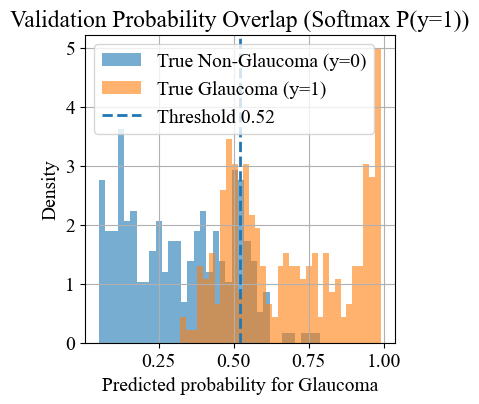

Best Youden threshold (from val) : 0.4560
Fixed threshold                  : 0.52


In [48]:
# Run inference on the validation set.
# # - Plots the probability distribution and computes the optimal Youden threshold.

val_dataset = datasets.ImageFolder(
    root=os.path.join(data_dir, "val"),
    transform=eval_transform
)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)
print(f"\nValidation set size: {len(val_dataset)} images")

y_val_true, y_val_prob = collect_probs(val_loader)
plot_overlap_hist(y_val_true, y_val_prob, bins=35, thr_line=FIXED_THRESHOLD)
best_threshold_youden  = youden_threshold(y_val_true, y_val_prob)
print(f"Best Youden threshold (from val) : {best_threshold_youden:.4f}")
print(f"Fixed threshold                  : {FIXED_THRESHOLD:.2f}")

In [49]:
# Run inference on the test set and collect predictions for final reporting.
test_dataset = datasets.ImageFolder(
    root=os.path.join(data_dir, "test"),
    transform=eval_transform
)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0)
print(f"\nTest set size: {len(test_dataset)} images")

y_true, y_prob = collect_probs(test_loader)


Test set size: 522 images


In [50]:
# Evaluate and report results using the fixed threshold (0.52).
thr_A = FIXED_THRESHOLD
m_A   = metrics_at_threshold(y_true, y_prob, thr_A)
ci_A  = bootstrap_ci(y_true, y_prob, thr_A)
print_results("Fixed Threshold = 0.52", m_A, ci_A, thr_A)


FINAL TEST RESULTS — Fixed Threshold = 0.52
Threshold : 0.5200    (Bootstrap n=1000, CI=95%)
Metric            Value                 95% CI
----------------------------------------------
AUC              0.9283   [0.9094 – 0.9478]
Accuracy         0.8218   [0.7912 – 0.8563]
Sensitivity      0.8245   [0.7796 – 0.8694]
Specificity      0.8195   [0.7726 – 0.8664]
Precision        0.8016   [0.7619 – 0.8443]
F1-score         0.8129   [0.7805 – 0.8486]

Confusion Matrix:
                Predicted
              Non-Glau  Glaucoma
True Non-Glau     227        50
True Glaucoma      43       202


In [51]:
# Evaluate and report results using the Youden-optimal threshold from validation.
thr_B = best_threshold_youden
m_B   = metrics_at_threshold(y_true, y_prob, thr_B)
ci_B  = bootstrap_ci(y_true, y_prob, thr_B)
print_results("Youden Threshold (from Val)", m_B, ci_B, thr_B)


FINAL TEST RESULTS — Youden Threshold (from Val)
Threshold : 0.4560    (Bootstrap n=1000, CI=95%)
Metric            Value                 95% CI
----------------------------------------------
AUC              0.9283   [0.9094 – 0.9478]
Accuracy         0.8084   [0.7759 – 0.8410]
Sensitivity      0.9429   [0.9143 – 0.9673]
Specificity      0.6895   [0.6354 – 0.7437]
Precision        0.7287   [0.6944 – 0.7672]
F1-score         0.8221   [0.7958 – 0.8495]

Confusion Matrix:
                Predicted
              Non-Glau  Glaucoma
True Non-Glau     191        86
True Glaucoma      14       231


In [52]:
# Save the threshold values and class mapping to a JSON file.
# # - Used later for inference or model fusion without re-running the notebook.

import json

thresholds_info = {
    "fixed_threshold":  float(FIXED_THRESHOLD),
    "youden_threshold": float(best_threshold_youden),
    "class_to_idx":     train_dataset.class_to_idx,
    "pos_class":        "B_glaucoma",
    "pos_idx":          1,
}

with open(r"D:\Rama\RetFound_thresholds.json", "w") as f:
    json.dump(thresholds_info, f, indent=4)

print("✓ Threshold config saved → LocalPublic_retfound_thresholds.json")

✓ Threshold config saved → LocalPublic_retfound_thresholds.json


In [53]:
y_true, y_prob = collect_probs(test_loader)
np.save(r"D:\Rama\retfound_true.npy", y_true)
np.save(r"D:\Rama\retfound_prob.npy", y_prob)
print("✓ Saved retfound_true.npy and retfound_prob.npy")

✓ Saved retfound_true.npy and retfound_prob.npy


## 1.7 Attention Rollout Visualization

Attention Rollout traces how attention flows from the input tokens through all transformer layers to identify which regions of the fundus image the model focuses on.  
The output is a heatmap overlaid on the original image — useful for interpretability and clinical validation.

**Parameters used:** `head_fusion='max'`, `discard_ratio=0.7`

In [52]:
# Import libraries required for Attention Rollout visualization.
# pytorch_grad_cam provides the rollout utilities; PIL and matplotlib handle image display.
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import numpy as np
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

In [88]:
# Load a single test image and prepare it in two formats:
# - img_np: normalized numpy array (0–1) used for visualization overlay.
# - img: original PIL image used for the inference transform pipeline.

img_path = r"D:\Rama\Glaucoma test\RETFound\RetFoundDatasets_60_20_20\test\B_glaucoma\glaucoma_hrf_hrf_000581_0d74d7c2.jpg"

img = Image.open(img_path).convert("RGB")

img_resized = img.resize((224, 224))
img_np = np.array(img_resized) / 255.0

In [89]:
# Apply the standard inference transform (resize + normalize with ImageNet stats).
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

input_tensor = inference_transform(img).unsqueeze(0).to(device)

# Run a forward pass to get the predicted class and confidence before generating the map.
with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1)
    pred_class = torch.argmax(probs, dim=1).item()
    pred_conf = probs[0, pred_class].item()

print(f"Predicted class: {pred_class} | Confidence: {pred_conf:.4f}")

Predicted class: 1 | Confidence: 0.5304


### Attention Rollout Function

Registers forward hooks on every transformer block to capture raw attention weights.
After the forward pass, hooks are removed and attention is processed in four steps:

| Step | Description |
|---|---|
| **Step 1** | Add residual connection (identity matrix) to each attention matrix |
| **Step 2** | Row-normalize so each token's attention sums to 1 |
| **Step 3** | Discard the lowest-attention tokens (controlled by `discard_ratio`) and re-normalize — this sharpens the final map |
| **Step 4** | Chain all layers via matrix multiplication (rollout) |

The output is a 2D spatial mask showing which image patches the model attended to most.

In [90]:
def attention_rollout_retfound(model, input_tensor, head_fusion="max", discard_ratio=0.7):
    all_attentions = []
    hooks = []

    def make_hook():
        def hook_fn(module, input, output):
            x_norm = input[0]
            B2, N, C = x_norm.shape
            qkv = module.qkv(x_norm)
            qkv = qkv.reshape(B2, N, 3, module.num_heads, C // module.num_heads).permute(2, 0, 3, 1, 4)
            q, k, v = qkv[0], qkv[1], qkv[2]
            attn = (q @ k.transpose(-2, -1)) * module.scale
            attn = attn.softmax(dim=-1)
            all_attentions.append(attn.detach().cpu())
        return hook_fn

    #  Hook ALL blocks (already correct in your code)
    for blk in model.blocks:
        h = blk.attn.register_forward_hook(make_hook())
        hooks.append(h)

    with torch.no_grad():
        _ = model(input_tensor)

    for h in hooks:
        h.remove()

    num_tokens = all_attentions[0].shape[-1]

    # Head fusion
    if head_fusion == "mean":
        attentions_fused = [attn.mean(dim=1) for attn in all_attentions]
    elif head_fusion == "max":
        attentions_fused = [attn.max(dim=1)[0] for attn in all_attentions]
    elif head_fusion == "min":
        attentions_fused = [attn.min(dim=1)[0] for attn in all_attentions]
    else:
        raise ValueError(f"Unknown head_fusion: {head_fusion}")

    rollout = torch.eye(num_tokens).unsqueeze(0)

    for attn in attentions_fused:
        #  FIX: Add residual FIRST, normalize, THEN discard

        # Step 1: Add residual
        attn_with_residual = attn + torch.eye(num_tokens).unsqueeze(0)

        # Step 2: Normalize
        attn_with_residual = attn_with_residual / attn_with_residual.sum(dim=-1, keepdim=True)

        # Step 3: Discard low attention AFTER residual
        if discard_ratio > 0:
            flat = attn_with_residual.view(attn_with_residual.shape[0], -1)
            num_keep = max(1, int(flat.shape[1] * (1 - discard_ratio)))
            sorted_attn, _ = torch.sort(flat, dim=1, descending=True)
            threshold = sorted_attn[:, num_keep - 1:num_keep]
            attn_with_residual = torch.where(
                attn_with_residual >= threshold.view(attn_with_residual.shape[0], 1, 1),
                attn_with_residual,
                torch.zeros_like(attn_with_residual)
            )
            # Re-normalize after discarding
            row_sums = attn_with_residual.sum(dim=-1, keepdim=True)
            row_sums = torch.where(row_sums == 0, torch.ones_like(row_sums), row_sums)
            attn_with_residual = attn_with_residual / row_sums

        # Step 4: Chain
        rollout = torch.matmul(attn_with_residual, rollout)

    mask = rollout[0, 0, 1:]
    grid_size = int(np.sqrt(mask.shape[0]))
    mask = mask.reshape(grid_size, grid_size).numpy()
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)

    return mask

In [91]:
# Run the Attention Rollout function on the input image.
# Resize the resulting spatial mask from patch-grid resolution (14×14) to 224×224
# using bilinear interpolation so it aligns with the original image for overlay.
attention_map = attention_rollout_retfound(
    model=model,
    input_tensor=input_tensor,
    head_fusion="max",
    discard_ratio=0.7
)

attention_map_resized = np.array(
    Image.fromarray(attention_map).resize((224, 224), Image.BILINEAR)
)

C:\Users\Rama Alotaibi\AppData\Local\Temp\ipykernel_21832\710803306.py:12: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:208.)
  attn = (q @ k.transpose(-2, -1)) * module.scale


In [92]:
from matplotlib import cm
colormap = cm.get_cmap('jet')
heatmap_colored = colormap(attention_map_resized)[:, :, :3]

C:\Users\Rama Alotaibi\AppData\Local\Temp\ipykernel_21832\4190849128.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('jet')


In [93]:
OUTPUT_DIR=r"D:\Rama\Rama_Final"

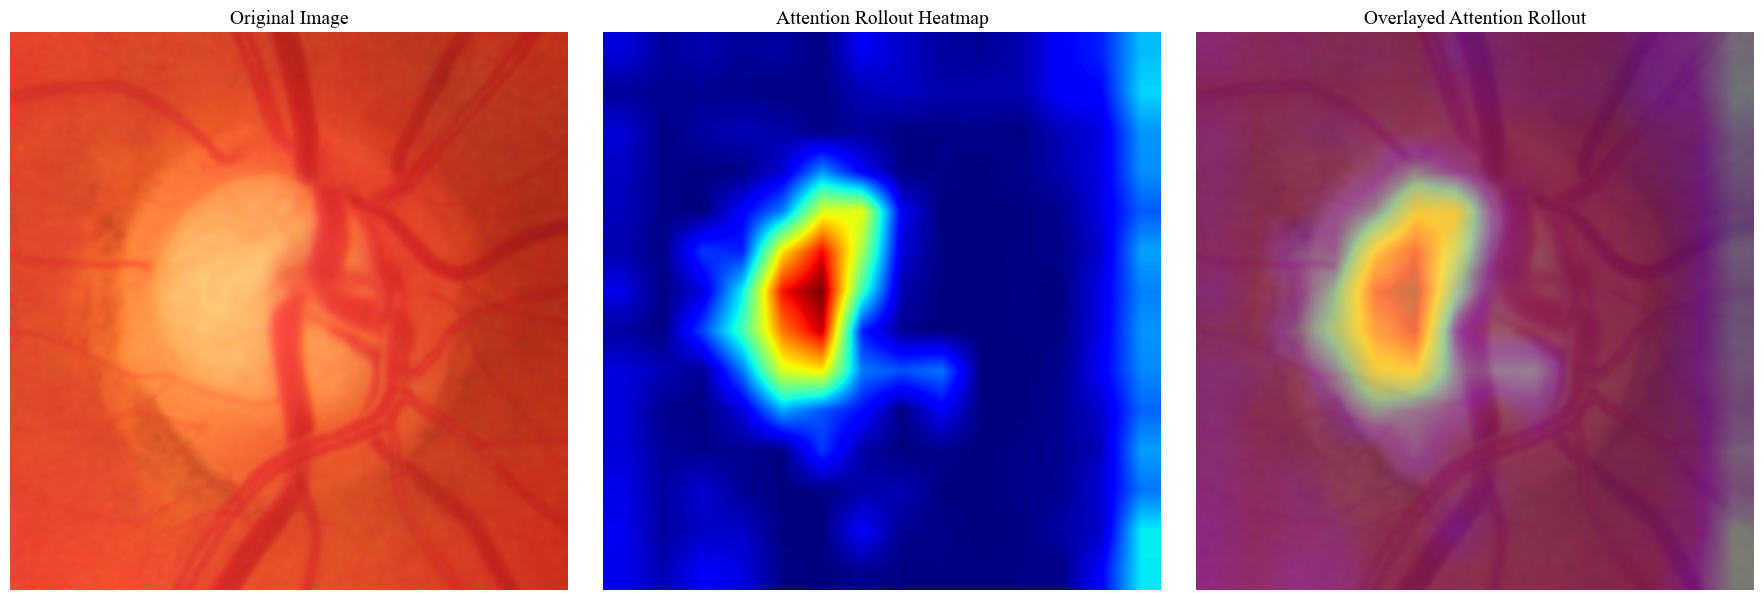

In [95]:
# ── Font settings ──────────────────────────────────────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14

class_names = {0: "Normal", 1: "Glaucoma"}
pred_label = class_names.get(pred_class, f"Class {pred_class}")

visualization = heatmap_colored * 0.4 + img_np * 0.6

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_np)
axes[0].set_title(f"Original Image", fontsize=14)
axes[0].axis("off")

axes[1].imshow(attention_map_resized, cmap="jet")
axes[1].set_title("Attention Rollout Heatmap", fontsize=14)
axes[1].axis("off")

axes[2].imshow(visualization)
axes[2].set_title("Overlayed Attention Rollout", fontsize=14)
axes[2].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "attention_rollout.png"), dpi=300, bbox_inches='tight')
plt.show()